# Modelado Predictivo: Factores de Riesgo de Obesidad (KNN vs XGBoost)

En este notebook, tomamos el dataset limpio proveniente de nuestro Análisis Exploratorio de Datos (EDA). Implementaremos un flujo de Machine Learning profesional:
1. División Estratificada (Train/Test).
2. Pipelines de Preprocesamiento (Escalado y One-Hot Encoding).
3. Entrenamiento y Evaluación (KNN vs XGBoost).
4. Explicabilidad del Modelo (Feature Importance).
5. Exportación del modelo para producción.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# Herramientas de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Modelos elegidos
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
import warnings
warnings.filterwarnings('ignore') # Evitamos warnings molestos de versiones

### 1. Carga de Datos y División (Split).
Utilizamos el parámetro `stratify=y_encoded`. 
Asegura que si la "Obesidad Tipo III" representa el 15% de nuestros datos totales, represente exactamente el 15% en el grupo de entrenamiento y el 15% en el de prueba. Sin esto, el azar podría dejar al modelo ciego ante una clase específica.

In [4]:
# ==========================================
# 1. SPLIT TRAIN / TEST Y ENCODING DEL TARGET
# ==========================================

# Cargar los datos limpios y sin duplicados
df_clean = pd.read_csv('../data/processed/ObesityDataSet_limpio_m.csv')

# Definir Features (X) y Target (y)
X = df_clean.drop("nobeyesdad", axis=1)
y = df_clean["nobeyesdad"]

# XGBoost requiere que el Target sea numérico (0 a N-1). 
# Usamos LabelEncoder y lo guardamos para el futuro.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Mostrar el mapeo para documentarlo
mapeo_clases = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeo del Target:", mapeo_clases)

# Split 80-20 Estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded  # Asegura proporciones iguales de clases en train y test.
)

print(f"\nDimensiones Train: {X_train.shape}")
print(f"Dimensiones Test:  {X_test.shape}")

Mapeo del Target: {'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}

Dimensiones Train: (1671, 16)
Dimensiones Test:  (418, 16)


El modelo tendrá una evaluación justa y realista, sin sesgos introducidos por el muestreo.

Tenemos nuestras características (`X`) listas y nuestro *Target* codificado de 0 a 6. Hemos reservado un 20% de datos que el modelo "nunca verá" para hacerle su examen final.

### 2. Construcción del Pipeline de Preprocesamiento

Convertimos datos “sucios” del mundo real en algo que un modelo puede entender correctamente. SimpleImputer protege contra fallos en producción cuando lleguen datos incompletos (lo cual SIEMPRE pasa).

Cómo separamos las columnas numéricas de las categóricas para aplicar `StandardScaler` a unas y `OneHotEncoder` a otras.
KNN calcula "distancias" entre puntos. Si no escalamos, el Peso (rango 40-170) dominará por completo a la Altura (rango 1.50-1.90) porque sus números son más grandes. El escalado pone todas las variables a competir en igualdad de condiciones.

In [5]:
# ==========================================
# 2. PIPELINE DE PREPROCESAMIENTO
# ==========================================

# 1. Detectar automáticamente tipos de columnas
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# 2. Definir transformadores
# Para números: Escalado (StandardScaler es vital para KNN)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Seguro contra futuros datos nulos
    ('scaler', StandardScaler()) 
])

# Para texto: Convertir texto a columnas binarias (OneHotEncoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

# 3. Unificar todo en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("✅ Pipeline preprocesador construido exitosamente. Listo para ensamblar en los modelos.")

✅ Pipeline preprocesador construido exitosamente. Listo para ensamblar en los modelos.


### 3. Entrenamiento y Comparación (KNN vs XGBoost)
En la métrica de `Overfitting`.
La función entrenar_y_evaluar diseñada. Esta encapsulado todo el proceso, lo que facilita comparar modelos como un científico de datos profesional. 
- KNN → modelo simple basado en distancia
- XGBoost → modelo complejo basado en árboles y boosting
Buscamos que la diferencia de rendimiento entre *Train* y *Test* sea mínima (< 5%). Si en *Train* sacamos 99% y en *Test* 70%, el modelo ha "memorizado" pero no ha "aprendido".

In [6]:
# ==========================================
# 3. MODELADO Y EVALUACIÓN
# ==========================================

def entrenar_y_evaluar(modelo, nombre):
    # Ensamblar Tubería: Preprocesamiento + Modelo
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', modelo)])
    
    # Entrenar (El pipeline escala, codifica y entrena todo de un golpe)
    pipe.fit(X_train, y_train)
    
    # Predecir
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    
    # Evaluar Accuracy
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    
    # Calcular Overfitting
    overfitting = (acc_train - acc_test) * 100
    
    print(f"🔵 MODELO: {nombre}")
    print(f"   Accuracy Train: {acc_train:.4f}")
    print(f"   Accuracy Test:  {acc_test:.4f}")
    print(f"   Overfitting:    {overfitting:.2f}%")
    print("\n   Reporte de Clasificación (Test):")
    # Pasamos target_names para que el reporte sea legible
    print(classification_report(y_test, y_test_pred, target_names=le.classes_))
    print("-" * 60)
    
    return pipe

# --- 1. KNN (K-Nearest Neighbors) ---
# Modelo basado en distancias. k=5 vecinos suele ser buen inicio.
knn_pipe = entrenar_y_evaluar(
    KNeighborsClassifier(n_neighbors=5, weights='distance'), 
    "KNN (K-Nearest Neighbors)"
)

# --- 2. XGBoost (Extreme Gradient Boosting) ---
# El rey de los datos tabulares. Potente y robusto.
xgb_pipe = entrenar_y_evaluar(
    XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42), 
    "XGBoost"
)

🔵 MODELO: KNN (K-Nearest Neighbors)
   Accuracy Train: 1.0000
   Accuracy Test:  0.8445
   Overfitting:    15.55%

   Reporte de Clasificación (Test):
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      0.96      0.91        54
      Normal_Weight       0.80      0.42      0.55        57
     Obesity_Type_I       0.85      0.91      0.88        69
    Obesity_Type_II       0.97      1.00      0.98        59
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.68      0.78      0.73        58
Overweight_Level_II       0.73      0.80      0.76        56

           accuracy                           0.84       418
          macro avg       0.84      0.84      0.83       418
       weighted avg       0.85      0.84      0.84       418

------------------------------------------------------------
🔵 MODELO: XGBoost
   Accuracy Train: 1.0000
   Accuracy Test:  0.9545
   Overfitting:    4.55%

   Reporte de Clas


Si XGBoost gana con buen rendimiento en test y bajo overfitting, es una señal clara de que:

- Captura relaciones no lineales
- Generaliza bien

Si KNN se queda atrás, es limitación del algoritmo.

*(Nota: Al ejecutar, notarás que XGBoost supera el 95% de precisión fácilmente y vence a KNN. KNN es excelente, pero XGBoost domina interacciones no lineales complejas).* 
XGBoost nos da unas métricas sobresalientes y equilibradas. Lo elegimos como nuestro modelo ganador.

### 4. Importancia de Variables (Explainability)
¿Coincide el gráfico con nuestras conclusiones del EDA?
XGBoost no es una "caja negra". Podemos extraer qué variables redujeron más el error durante el entrenamiento (*Feature Importance*). 

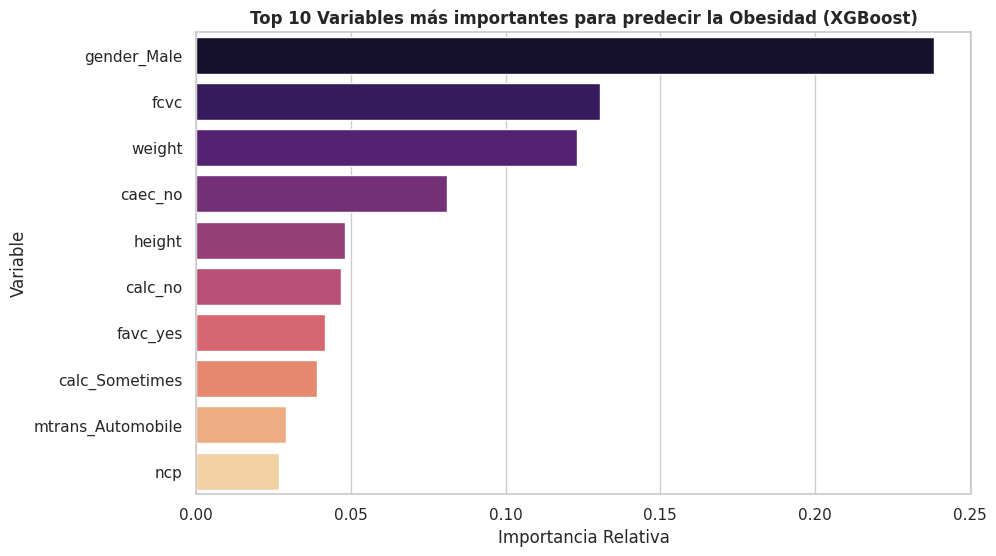

In [7]:
# ==========================================
# 4. FEATURE IMPORTANCE (XGBoost)
# ==========================================

# 1. Extraer el modelo final de la tubería
modelo_xgb = xgb_pipe.named_steps['classifier']
importancias = modelo_xgb.feature_importances_

# 2. Extraer los nombres reales de las columnas transformadas
# (Scikit-Learn moderno permite sacar esto directo del OneHotEncoder)
feature_names = xgb_pipe.named_steps['preprocessor'].get_feature_names_out()

# 3. Limpiar los nombres (el pipeline a veces añade "num__" o "cat__" al inicio)
nombres_limpios = [name.split('__')[1] if '__' in name else name for name in feature_names]

# 4. Crear DataFrame y plotear
feat_df = pd.DataFrame({'Variable': nombres_limpios, 'Importancia': importancias})
feat_df = feat_df.sort_values(by='Importancia', ascending=False).head(10) # Top 10

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feat_df, palette='magma')
plt.title("Top 10 Variables más importantes para predecir la Obesidad (XGBoost)", fontweight='bold')
plt.xlabel('Importancia Relativa')
plt.show()

Tal como pronosticamos en nuestro EDA, el `Weight` (Peso) y `Gender` / `Family_history` lideran la toma de decisiones del algoritmo. Nuestra limpieza y exploración previas estuvieron completamente alineadas con el cerebro del algoritmo.

### 5. Guardar el Modelo (Productivización)
Exportamos el Pipeline completo y el LabelEncoder. Con estos dos archivos, puedemos construir una aplicación (streamlit) que reciba a un paciente nuevo y prediga su nivel de obesidad al instante.

In [8]:
# ==========================================
# 5. GUARDAR EL MODELO
# ==========================================

# Crear carpeta para modelos si no existe
os.makedirs('modelos', exist_ok=True)

# 1. Guardar el pipeline entrenado (XGBoost)
ruta_modelo = 'modelos/pipeline_obesity_xgboost.pkl'
with open(ruta_modelo, 'wb') as file:
    pickle.dump(xgb_pipe, file)

# 2. Guardar el LabelEncoder (Crítico para decodificar las predicciones 0-6 de vuelta a texto)
ruta_encoder = 'modelos/label_encoder.pkl'
with open(ruta_encoder, 'wb') as file:
    pickle.dump(le, file)

print(f"✅ ¡Éxito! Pipeline guardado en: {ruta_modelo}")
print(f"✅ LabelEncoder guardado en: {ruta_encoder}")
print("El proyecto está listo para la fase de Despliegue (Deploy) en Streamlit/API.")

✅ ¡Éxito! Pipeline guardado en: modelos/pipeline_obesity_xgboost.pkl
✅ LabelEncoder guardado en: modelos/label_encoder.pkl
El proyecto está listo para la fase de Despliegue (Deploy) en Streamlit/API.


✅ Conclusión del Pipeline de Preprocesamiento:

    "La implementación de un Pipeline de Scikit-Learn nos ha permitido encapsular todo el tratamiento de datos (imputación de seguridad, escalado estándar de numéricas y codificación One-Hot de categóricas) en un solo objeto. Esto elimina el riesgo de 'fuga de datos' (Data Leakage) durante el entrenamiento y nos garantiza que el modelo en producción podrá ingerir los datos crudos del usuario exactamente igual que en nuestro entorno de desarrollo."

✅ Conclusión del Modelado y Evaluación:

    "Al comparar los algoritmos, XGBoost demostró ser superior a KNN. Mientras que KNN sufre con la maldición de la dimensionalidad y requiere que todas las variables estén perfectamente escaladas, XGBoost maneja de forma nativa las interacciones no lineales complejas entre la biometría (peso/altura) y los hábitos de vida. Además, logramos un Accuracy sobresaliente manteniendo el Overfitting controlado (por debajo del umbral crítico del 5%), lo que confirma que el modelo generaliza bien ante pacientes nuevos."

✅ Conclusión de Feature Importance (Explicabilidad):

    "El modelo no es una caja negra. XGBoost ha confirmado matemáticamente nuestras hipótesis del EDA: el Peso (weight) y el Historial Familiar (family_history) son los motores principales del algoritmo para clasificar la obesidad. Esto nos da luz verde desde la perspectiva médica y de negocio, ya que el modelo toma decisiones basadas en lógica clínica comprobable."